## Chapter 8: Distilling Reasoning Models for Efficient Reasoning

In [3]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

reasoning_from_scratch version: 0.1.16
torch version: 2.10.0
tokenizers version: 0.22.2


In [4]:
import json
import requests
from pathlib import Path


def load_distill_data(
    local_path=None,
    partition="deepseek-r1-math-train",
    save_copy=True,
):

    if local_path is None:
        local_path = f"{partition}.json"
    local_path = Path(local_path)

    url = (
        "https://huggingface.co/datasets/rasbt/math_distill"
        "/resolve/main/data/"
        f"{partition}.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        f"MATH/{partition}.json"
    )

    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB (cached)")
        return data

    assert partition in (
        "deepseek-r1-math-train",
        "deepseek-r1-math500",
        "qwen3-235b-a22b-math-train",
        "qwen3-235b-a22b-math500",
    )

    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
    except requests.RequestException:
        print("Using backup URL.")
        r = requests.get(backup_url, timeout=30)
        r.raise_for_status()

    data = r.json()

    if save_copy:
        with local_path.open("w", encoding="utf-8") as f:
            json.dump(data, f, indent=2)

        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB")

    return data

In [5]:
math_train = load_distill_data(partition="deepseek-r1-math-train")

print("Dataset size:", len(math_train))

deepseek-r1-math-train.json: 107538.0 KB (cached)
Dataset size: 12000


In [6]:
from pprint import pprint

pprint(math_train[4])

{'gtruth_answer': '6',
 'message_content': 'Sam worked \\( x \\) days and did not work \\( y \\) '
                    'days. We know:\n'
                    '\\[\n'
                    'x + y = 20\n'
                    '\\]\n'
                    'His total earnings are calculated as:\n'
                    '\\[\n'
                    '60x - 30y = 660\n'
                    '\\]\n'
                    'Substituting \\( x = 20 - y \\) into the earnings '
                    'equation:\n'
                    '\\[\n'
                    '60(20 - y) - 30y = 660\n'
                    '\\]\n'
                    'Simplifying:\n'
                    '\\[\n'
                    '1200 - 60y - 30y = 660 \\\\\n'
                    '1200 - 90y = 660 \\\\\n'
                    '-90y = 660 - 1200 \\\\\n'
                    '-90y = -540 \\\\\n'
                    'y = \\frac{-540}{-90} = 6\n'
                    '\\]\n'
                    'Sam did not work \\(\\boxed{6}\\) days.',
 'message_t

In [7]:
math_train[4].keys()

dict_keys(['problem', 'gtruth_answer', 'message_thinking', 'message_content'])

In [8]:
def format_distilled_answer(entry):
    content = str(entry["message_content"]).strip()
    if not content:
        raise ValueError("Missing non-empty 'message_content' field.")
    thinking = str(entry["message_thinking"]).strip()
    return f"<think>{thinking}</think>\n\n{content}"

In [9]:
print(format_distilled_answer(math_train[4]))

<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? Is it that he loses $30 per day not worked from his total earnings?

Wait, maybe. So if he didn't work y days, then he loses 30*y dollars. But wait, does he get a base salary and then deductions? Or is his total earnings 60x minus 30y?

The problem says, "On days that he works, he earns $60. For each day that he does not work, $30 is subtracted from his earnings." So probably, his total earnings are calculated by 60

In [12]:
from reasoning_from_scratch.ch07 import download_from_github

_ = download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_json.py"
)

evaluate_json.py: 3.3 KB


In [13]:
!uv run evaluate_json.py \
--json_path "deepseek-r1-math-train.json" \
--gtruth_answer gtruth_answer \
--generated_text message_content

Accuracy: 90.6% (10871/12000)


In [14]:
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Tokenizer
)

def load_reasoning_tokenizer(local_dir="qwen3"):
    download_qwen3_small(
        kind="reasoning", tokenizer_only=True, out_dir=local_dir
    )

    tokenizer_path = Path(local_dir) / "tokenizer-reasoning.json"
    tokenizer = Qwen3Tokenizer(
        tokenizer_file_path=tokenizer_path,
        apply_chat_template=True,
        add_generation_prompt=True,
        add_thinking=True,
    )
    
    return tokenizer


tokenizer = load_reasoning_tokenizer()

tokenizer-reasoning.json: 100% (10 MiB / 10 MiB)


In [15]:
prompt = "Sam is hired for a 20-day period..."

prompt_ids = tokenizer.encode(prompt)
decoded_prompt = tokenizer.decode(prompt_ids)
print(decoded_prompt)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant



In [16]:
answer = (
    "<think>Okay, let me try to solve "
    "this problem...</think> \\boxed{4}"
)
answer_ids = tokenizer.encode(answer, chat_wrapped=False)
decoded_answer = tokenizer.decode(answer_ids)
print(decoded_answer)

<think>Okay, let me try to solve this problem...</think> \boxed{4}


In [17]:
token_ids = prompt_ids + answer_ids + [tokenizer.eos_token_id]
decoded_token_ids = tokenizer.decode(token_ids)
print(decoded_token_ids)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant
<think>Okay, let me try to solve this problem...</think> \boxed{4}<|im_end|>


In [19]:
from reasoning_from_scratch.ch03 import render_prompt

def build_examples(data, tokenizer):
    examples = []
    skipped = 0

    for entry in data:
        try:
            prompt = render_prompt(entry["problem"])
            prompt_ids = tokenizer.encode(prompt)
    
            target_answer = format_distilled_answer(entry)
            answer_ids = tokenizer.encode(
                target_answer, chat_wrapped = False
            )

            token_ids = (
                prompt_ids + answer_ids + [tokenizer.eos_token_id]
            )

            if len(token_ids) < 2:
                skipped += 1
                continue
            examples.append({
                "token_ids": token_ids,
                "prompt_len": len(prompt_ids),
            })
        except (KeyError, TypeError, ValueError):
            skipped += 1
    return examples, skipped

In [20]:
examples, skipped = build_examples(math_train, tokenizer)

print("Number of examples:", len(examples))
print("Number of skipped examples:", skipped)

Number of examples: 12000
Number of skipped examples: 0


In [21]:
print(tokenizer.decode(examples[4]["token_ids"]))

<|im_start|>user
You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Sam is hired for a 20-day period. On days that he works, he earns $\$$60. For each day that he does not work, $\$$30 is subtracted from his earnings. At the end of the 20-day period, he received $\$$660. How many days did he not work?

Answer:<|im_end|>
<|im_start|>assistant
<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? I

In [31]:
def compute_length(examples, answer_only=False):
    lengths = []
    for ex in examples:
        total = len(ex["token_ids"])
        length = total - ex["prompt_len"] if answer_only else total
        lengths.append(length)
    avg_len = round(sum(lengths) / len(lengths))

    shortest_len = min(lengths)
    longest_len = max(lengths)
    shortest_idx = lengths.index(shortest_len)
    longest_idx = lengths.index(longest_len)

    print(f"Average: {avg_len} tokens")
    print(f"Shortest: {shortest_len} tokens (index {shortest_idx})")
    print(f"Longest: {longest_len} tokens (index {longest_idx})")

compute_length(examples)


Average: 2946 tokens
Shortest: 236 tokens (index 10846)
Longest: 42005 tokens (index 2529)


In [32]:
def filter_examples_by_max_len(examples, max_len=2048):
    filtered_examples = [
        s for s in examples
        if len(s["token_ids"]) <= max_len
    ]

    print("Original:", len(examples))
    print("Filtered:", len(filtered_examples))
    print("Removed:", len(examples) - len(filtered_examples))

    return filtered_examples

filtered_examples = filter_examples_by_max_len(examples, max_len=2048)

Original: 12000
Filtered: 6695
Removed: 5305


In [33]:
compute_length(filtered_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5971)
Longest: 2048 tokens (index 5587)


In [34]:
import random

rng = random.Random(123)
rng.shuffle(filtered_examples)

train_examples = filtered_examples[25:]
val_examples = filtered_examples[:25]

In [35]:
print("Number of train examples:", len(train_examples))
print("Number of validation examples:", len(val_examples))

Number of train examples: 6670
Number of validation examples: 25


In [36]:
compute_length(train_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5730)
Longest: 2048 tokens (index 1319)


In [37]:
compute_length(val_examples)

Average: 1106 tokens
Shortest: 481 tokens (index 15)
Longest: 1918 tokens (index 12)


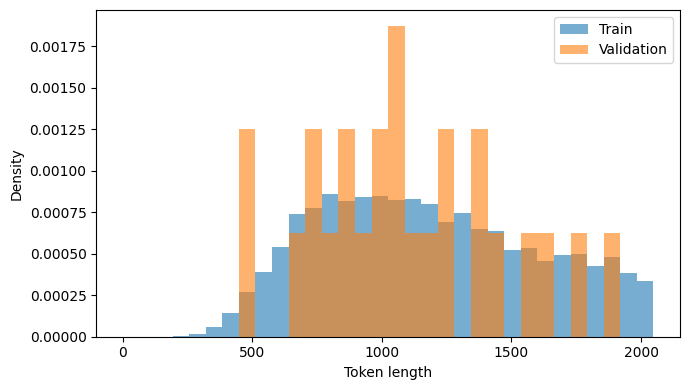

In [38]:
import matplotlib.pyplot as plt

train_lengths = [len(ex["token_ids"]) for ex in train_examples]
val_lengths = [len(ex["token_ids"]) for ex in val_examples]

# Normalize counts because the validation split is much smaller
bins = range(0, max(train_lengths + val_lengths) + 64, 64)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_lengths, bins=bins, density=True, alpha=0.6, label="Train")
ax.hist(val_lengths, bins=bins, density=True, alpha=0.6, label="Validation")
ax.set_xlabel("Token length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
import torch

from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()

model, _ = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
Primary URL (https://huggingface.co/rasbt/qwen3-from-scratch/resolve/main/qwen3-0.6B-base.pth) failed.
Trying backup URL (https://f001.backblazeb2.com/file/reasoning-from-scratch/qwen3-0.6B/qwen3-0.6B-base.pth)...
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)
